In [6]:
from pathlib import Path

In [7]:
df= pd.read_csv(Path("outputs") / "df.csv")

In [1]:
# ============================================================
# Case 2 figures notebook block (SEA days, fuel, add-ons)
# Requires: df from Case 1 notebook
# df columns expected: scenario, corridor, variant, method, distance_nm, distance_knm
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
# ----------------------------
# 0) Inputs / settings
# ----------------------------
OUTDIR = "figures"
os.makedirs(OUTDIR, exist_ok=True)

# Corridor order (paper order)
CORRIDOR_ORDER = ["SUEZ", "NSR", "CAPE"]

# Waypoint philosophy order
VARIANT_ORDER = ["service", "bluewater", "coast"]  # adjust if your label differs

# Corridor-typical service speeds (kn)
SPEEDS_KN = {
    "NSR": 12.5,
    "SUEZ": 14.5,
    "CAPE": 14.0
}

# --- Fuel model defaults (only used if df lacks fuel columns) ---
# Reference speed for cubic scaling
REF_SPEED_KN = 14.0

# Main-engine fuel rate at REF_SPEED (t/day) per corridor
# (if you want exact match to your pipeline, overwrite these with your values)
ME_FUEL_TPD_REF = {
    "NSR": 40.0,
    "SUEZ": 48.0,
    "CAPE": 47.0
}

# Auxiliary fuel rate (t/day), assumed constant
AUX_FUEL_TPD = {
    "NSR": 3.5,
    "SUEZ": 3.5,
    "CAPE": 3.5
}

EF_CO2 = 3.114  # tCO2 / t fuel

In [11]:
# ----------------------------
# 1) Prepare SEA dataframe
# ----------------------------
assert "df" in globals(), "df not found. Run Case 0/1 distance notebook first."

sea_df = df[df["method"].str.upper() == "SEA"].copy()

# Clean corridor/variant labels
sea_df["corridor"] = sea_df["corridor"].str.upper()
sea_df["variant"]  = sea_df["variant"].str.lower()

# Keep only expected corridors
sea_df = sea_df[sea_df["corridor"].isin(CORRIDOR_ORDER)].copy()

# Enforce ordering for plots
sea_df["corridor"] = pd.Categorical(sea_df["corridor"], CORRIDOR_ORDER, ordered=True)
sea_df["variant"]  = pd.Categorical(sea_df["variant"], VARIANT_ORDER, ordered=True)
sea_df = sea_df.sort_values(["corridor", "variant", "scenario"]).reset_index(drop=True)

# Ensure distance columns exist
if "distance_nm" not in sea_df.columns:
    raise ValueError("sea_df missing distance_nm. Check df build.")
if "distance_knm" not in sea_df.columns:
    sea_df["distance_knm"] = sea_df["distance_nm"] / 1000.0

In [13]:
# ----------------------------
# 2) Compute days, fuel, CO2 if not already there
# ----------------------------
# Days under corridor-typical speeds
if "time_days" not in sea_df.columns:
    sea_df["speed_kn"] = sea_df["corridor"].map(SPEEDS_KN).astype(float)
    sea_df["time_days"] = sea_df["distance_nm"] / (sea_df["speed_kn"] * 24.0)

# Fuel + CO2 (use existing if present, else compute)
if "fuel_t" not in sea_df.columns:
    # cubic scaling for ME fuel per-day
    def me_tpd(corr):
        U = SPEEDS_KN[corr]
        return ME_FUEL_TPD_REF[corr] * (U / REF_SPEED_KN) ** 3

    sea_df["me_tpd"]  = sea_df["corridor"].astype(str).map(me_tpd)
    sea_df["aux_tpd"] = sea_df["corridor"].astype(str).map(AUX_FUEL_TPD).astype(float)
    sea_df["fuel_t"]  = (sea_df["me_tpd"] + sea_df["aux_tpd"]) * sea_df["time_days"]

if "co2_t" not in sea_df.columns:
    sea_df["co2_t"] = sea_df["fuel_t"] * EF_CO2

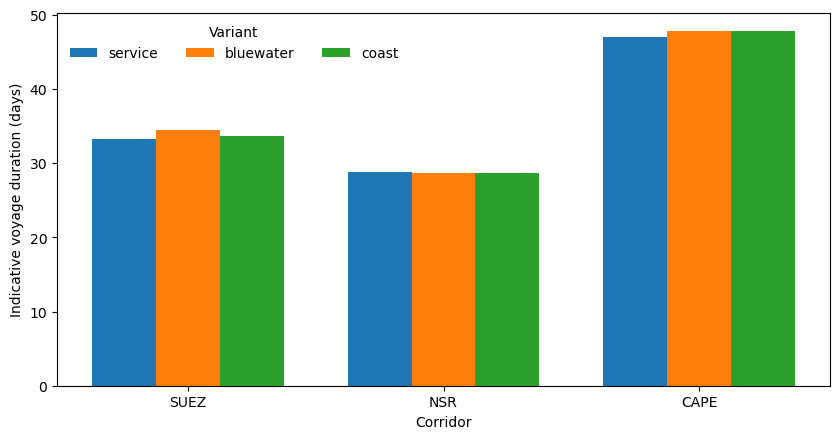

In [14]:
# ----------------------------
# 3) Figure A: BASELINE_days.png
# ----------------------------
plt.figure(figsize=(8.5, 4.5))

# grouped bars: x = corridor, bars = variants
x = np.arange(len(CORRIDOR_ORDER))
width = 0.25

for i, v in enumerate(VARIANT_ORDER):
    sub = sea_df[sea_df["variant"] == v].set_index("corridor").reindex(CORRIDOR_ORDER)
    plt.bar(x + (i-1)*width, sub["time_days"].values, width=width, label=v)

plt.xticks(x, CORRIDOR_ORDER)
plt.ylabel("Indicative voyage duration (days)")
plt.xlabel("Corridor")
plt.legend(title="Variant", frameon=False, ncol=3)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "BASELINE_days.png"), dpi=300)
plt.show()

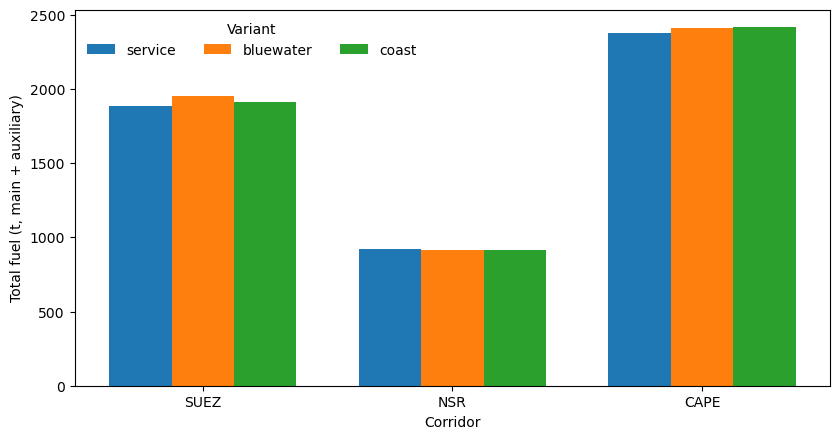

In [15]:
# ----------------------------
# 4) Figure B: BASELINE_fuel.png
# ----------------------------
plt.figure(figsize=(8.5, 4.5))

for i, v in enumerate(VARIANT_ORDER):
    sub = sea_df[sea_df["variant"] == v].set_index("corridor").reindex(CORRIDOR_ORDER)
    plt.bar(x + (i-1)*width, sub["fuel_t"].values, width=width, label=v)

plt.xticks(x, CORRIDOR_ORDER)
plt.ylabel("Total fuel (t, main + auxiliary)")
plt.xlabel("Corridor")
plt.legend(title="Variant", frameon=False, ncol=3)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "BASELINE_fuel.png"), dpi=300)
plt.show()

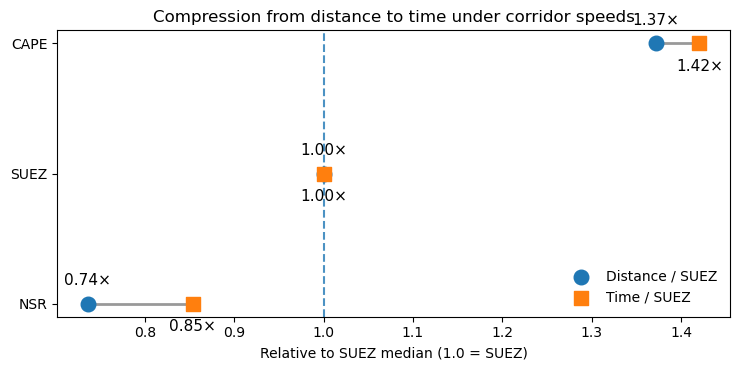

Saved: figures/BASELINE_dist_time_rel_dumbbell.png


In [20]:
# ----------------------------
# 5) Distance→Time compression dumbbell (relative to SUEZ)
# ----------------------------
import numpy as np
import matplotlib.pyplot as plt
import os

# --- build corridor medians from sea_df ---
med = (sea_df
       .groupby("corridor", observed=True)
       .agg(distance_nm_med=("distance_nm", "median"),
            time_days_med=("time_days", "median"))
       .reindex(CORRIDOR_ORDER))

# --- relative to SUEZ median ---
suez_dist = med.loc["SUEZ", "distance_nm_med"]
suez_time = med.loc["SUEZ", "time_days_med"]

med["distance_rel"] = med["distance_nm_med"] / suez_dist
med["time_rel"]     = med["time_days_med"] / suez_time

# ----------------------------
# Distance→Time compression dumbbell (relative to SUEZ)
# ----------------------------
plt.figure(figsize=(7.5, 3.8))
ypos = np.arange(len(CORRIDOR_ORDER))

for i, corr in enumerate(CORRIDOR_ORDER):
    d_rel = med.loc[corr, "distance_rel"]
    t_rel = med.loc[corr, "time_rel"]

    # neutral connector
    plt.plot([d_rel, t_rel], [i, i], color="0.6", linewidth=2, zorder=1)

    # fixed semantic colors
    plt.scatter(d_rel, i, marker="o", s=110, color="tab:blue",
                label="Distance / SUEZ" if i == 0 else None, zorder=3)
    plt.scatter(t_rel, i, marker="s", s=110, color="tab:orange",
                label="Time / SUEZ" if i == 0 else None, zorder=3)

    # numeric labels
    plt.text(d_rel, i + 0.12, f"{d_rel:.2f}×", ha="center", va="bottom", fontsize=11)
    plt.text(t_rel, i - 0.12, f"{t_rel:.2f}×", ha="center", va="top", fontsize=11)

plt.axvline(1.0, linestyle="--", linewidth=1.5, color="tab:blue", alpha=0.8)
plt.yticks(ypos, CORRIDOR_ORDER)
plt.xlabel("Relative to SUEZ median (1.0 = SUEZ)")
plt.title("Compression from distance to time under corridor speeds")
plt.legend(frameon=False, loc="lower right")
plt.tight_layout()

outpath = os.path.join(OUTDIR, "BASELINE_dist_time_rel_dumbbell.png")
plt.savefig(outpath, dpi=300)
plt.show()

print("Saved:", outpath)

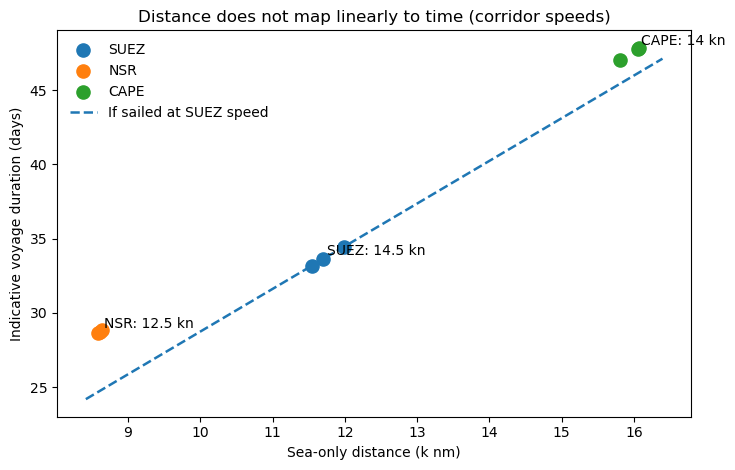

In [26]:
# ----------------------------
# 6) Add-on 2: Scatter distance (knm) vs days (corridor speeds)
# ----------------------------

# Expect sea_df with at least: corridor, variant, distance_nm (SEA-only)
# If you stored distance_knm already, that's fine too.
if "distance_knm" not in sea_df.columns:
    sea_df["distance_knm"] = sea_df["distance_nm"] / 1000.0

# Corridor-typical speeds (kn = nm/h) used in the paper
SPEEDS = {"NSR": 12.5, "SUEZ": 14.5, "CAPE": 14.0}

# If time_days not present, compute it from SEA distance + corridor speed
if "time_days" not in sea_df.columns:
    sea_df["time_days"] = sea_df.apply(
        lambda r: (r["distance_nm"] / SPEEDS[r["corridor"]]) / 24.0, axis=1
    )

OUTDIR = "figures"  # change if you want
os.makedirs(OUTDIR, exist_ok=True)

plt.figure(figsize=(7.5, 4.8))

# Scatter per corridor (no manual colors -> matplotlib default cycle)
for corr, sub in sea_df.groupby("corridor", observed=True):
    plt.scatter(sub["distance_knm"], sub["time_days"], s=90, label=corr)

# Reference line: "if all corridors sailed at SUEZ speed"
U_SUEZ = SPEEDS["SUEZ"]
x_min = sea_df["distance_knm"].min() * 0.98
x_max = sea_df["distance_knm"].max() * 1.02
x_line = np.linspace(x_min, x_max, 200)
t_line_days = (x_line * 1000.0 / U_SUEZ) / 24.0
plt.plot(x_line, t_line_days, linestyle="--", linewidth=1.8,
         label="If sailed at SUEZ speed")

# Annotate each corridor cluster with its speed
med = (sea_df.groupby("corridor", observed=True)
              .agg(x=("distance_knm","median"),
                   y=("time_days","median"))
      )
for corr, row in med.iterrows():
    sp = SPEEDS[corr]
    plt.text(row["x"] + 0.05, row["y"] + 0.25, f"{corr}: {sp:g} kn")

plt.xlabel("Sea-only distance (k nm)")
plt.ylabel("Indicative voyage duration (days)")
plt.title("Distance does not map linearly to time (corridor speeds)")
plt.legend(frameon=False, loc="upper left")
plt.tight_layout()

plt.savefig(os.path.join(OUTDIR, "BASELINE_dist_vs_days_scatter_upgraded.png"), dpi=300)
plt.show()

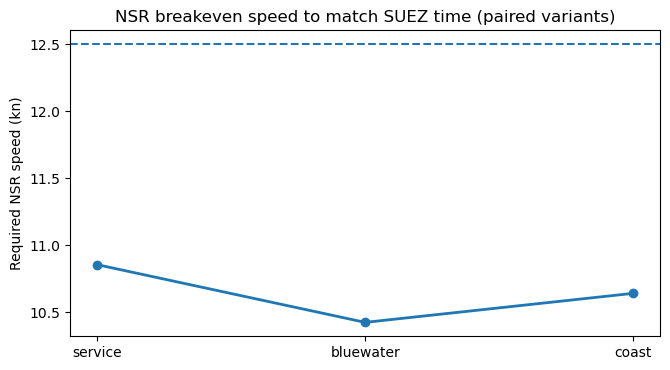

              scenario corridor    variant  distance_knm  time_days  \
0    SUEZ_VAR1_service     SUEZ    service     11.545575  33.176939   
1  SUEZ_VAR2_bluewater     SUEZ  bluewater     11.981478  34.429534   
2      SUEZ_VAR3_coast     SUEZ      coast     11.703988  33.632150   
3     NSR_VAR1_service      NSR    service      8.642788  28.809294   
4   NSR_VAR2_bluewater      NSR  bluewater      8.612982  28.709940   
5       NSR_VAR3_coast      NSR      coast      8.588469  28.628231   
6    CAPE_VAR1_service     CAPE    service     15.803021  47.032799   
7  CAPE_VAR2_bluewater     CAPE  bluewater     16.051906  47.773529   
8      CAPE_VAR3_coast     CAPE      coast     16.073355  47.837365   

        fuel_t        co2_t  
0  1885.402871  5871.144539  
1  1956.586246  6092.809570  
2  1911.271955  5951.700867  
3   921.067973  2868.205669  
4   917.891511  2858.314167  
5   915.279183  2850.179375  
6  2375.156364  7396.236917  
7  2412.563204  7512.721817  
8  2415.786937  752

In [23]:
# ----------------------------
# 7) Add-on 3: Breakeven NSR speed to match SUEZ time
# ----------------------------
# Pair by philosophy: NSR_service vs SUEZ_service, etc.
nsr_sub  = sea_df[sea_df["corridor"]=="NSR"].set_index("variant")
suez_sub = sea_df[sea_df["corridor"]=="SUEZ"].set_index("variant")

breakeven_rows = []
for v in VARIANT_ORDER:
    if v in nsr_sub.index and v in suez_sub.index:
        D_nsr = float(nsr_sub.loc[v, "distance_nm"])
        T_suez_days = float(suez_sub.loc[v, "time_days"])
        U_break = D_nsr / (T_suez_days*24.0)
        breakeven_rows.append({"variant": v, "U_break_kn": U_break})

breakeven_df = pd.DataFrame(breakeven_rows).set_index("variant").reindex(VARIANT_ORDER)

plt.figure(figsize=(6.8, 3.8))
plt.plot(np.arange(len(VARIANT_ORDER)), breakeven_df["U_break_kn"], marker="o", linewidth=2)
plt.axhline(SPEEDS_KN["NSR"], linestyle="--", linewidth=1.5)
plt.xticks(np.arange(len(VARIANT_ORDER)), VARIANT_ORDER)
plt.ylabel("Required NSR speed (kn)")
plt.title("NSR breakeven speed to match SUEZ time (paired variants)")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "BASELINE_nsr_breakeven_speed.png"), dpi=300)
plt.show()

# ----------------------------
# 8) Quick sanity print
# ----------------------------
print(sea_df[["scenario","corridor","variant","distance_knm","time_days","fuel_t","co2_t"]])
print("\nCorridor medians used for rank dumbbell:")
print(med)
print("\nNSR breakeven speeds (kn):")
print(breakeven_df)